In [1]:

import os
import warnings
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon, t

warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
CLASSICAL_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"
QML_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_qml_baselines_balanced_pca12_reduced50_20.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output"
os.makedirs(OUT_DIR, exist_ok=True)

PCA_K = 12
DATASET_NAME = "balanced"

# choose only the baselines you want in the paper
CLASSICAL_MODELS = ["SVM", "RandomForest", "CatBoost", "XGBoost"]
QML_MODELS = ["QSVM_Z", "QSVM_Pauli"]

# primary metrics for significance analysis
METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier", "ECE"]

# lower is better for these metrics
LOWER_BETTER = ["Brier", "ECE"]

# ============================================================
# HELPERS
# ============================================================
def load_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n{path}")
    return pd.read_csv(path)

def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    mean_ = np.mean(arr)
    std_ = np.std(arr, ddof=1) if n > 1 else 0.0
    if n <= 1:
        return mean_, std_, mean_, mean_
    tcrit = t.ppf(0.975, df=n - 1)
    margin = tcrit * (std_ / np.sqrt(n))
    return mean_, std_, mean_ - margin, mean_ + margin

def safe_paired_ttest(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) != len(b):
        raise ValueError("Inputs must have same length for paired t-test")

    if np.allclose(a, b):
        return 0.0, 1.0

    stat, p = ttest_rel(a, b)
    return float(stat), float(p)

def safe_wilcoxon(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) != len(b):
        raise ValueError("Inputs must have same length for Wilcoxon test")

    diff = a - b
    if np.allclose(diff, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan

def cohens_d_paired(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = a - b
    sd = np.std(d, ddof=1)
    if np.isclose(sd, 0.0):
        return np.inf if not np.isclose(np.mean(d), 0.0) else 0.0
    return float(np.mean(d) / sd)

def effect_size_label(d):
    ad = abs(d)
    if np.isinf(ad):
        return "very large"
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

def significance_label(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def fmt_pm(mean_, std_):
    return f"{mean_:.4f} ± {std_:.4f}"

# ============================================================
# LOAD DATA
# ============================================================
proposed_df = load_csv(PROPOSED_CSV)
classical_df = load_csv(CLASSICAL_CSV)
qml_df = load_csv(QML_CSV)

# ============================================================
# FILTER TO PCA-12 ONLY
# ============================================================
proposed_df = proposed_df[
    (proposed_df["Dataset"] == DATASET_NAME) &
    (proposed_df["PCA"] == PCA_K)
].copy()

classical_df = classical_df[
    (classical_df["Dataset"] == DATASET_NAME) &
    (classical_df["PCA"] == PCA_K) &
    (classical_df["Algorithm"].isin(CLASSICAL_MODELS))
].copy()

qml_df = qml_df[
    (qml_df["Dataset"] == DATASET_NAME) &
    (qml_df["PCA"] == PCA_K) &
    (qml_df["Algorithm"].isin(QML_MODELS))
].copy()

# keep only seeds common with proposed
common_seeds = sorted(set(proposed_df["Seed"].unique()))
classical_df = classical_df[classical_df["Seed"].isin(common_seeds)].copy()
qml_df = qml_df[qml_df["Seed"].isin(common_seeds)].copy()

proposed_df = proposed_df.sort_values("Seed").reset_index(drop=True)

# ============================================================
# BUILD MODEL TABLES
# ============================================================
rows = []

# proposed self summary
for metric in METRICS:
    pvals = proposed_df.sort_values("Seed")[metric].values
    p_mean, p_std, p_lo, p_hi = ci95(pvals)

    rows.append({
        "Dataset": DATASET_NAME,
        "PCA": PCA_K,
        "Comparison": "AIG-QFusion",
        "Metric": metric,
        "Proposed_Mean±Std": fmt_pm(p_mean, p_std),
        "Baseline_Mean±Std": "-",
        "Proposed_CI95": f"[{p_lo:.4f}, {p_hi:.4f}]",
        "Baseline_CI95": "-",
        "Mean_Diff": np.nan,
        "Paired_t_stat": np.nan,
        "Paired_t_p": np.nan,
        "Wilcoxon_stat": np.nan,
        "Wilcoxon_p": np.nan,
        "Cohens_d_paired": np.nan,
        "Effect_Size": "-",
        "Significance": "-",
        "Proposed_better": "-"
    })

def compare_against_baseline(baseline_df, baseline_name):
    base_sub = baseline_df[baseline_df["Algorithm"] == baseline_name].copy()
    if base_sub.empty:
        return

    base_sub = base_sub.sort_values("Seed").reset_index(drop=True)

    merged = proposed_df[["Seed"] + METRICS].merge(
        base_sub[["Seed"] + METRICS],
        on="Seed",
        suffixes=("_prop", "_base")
    ).sort_values("Seed").reset_index(drop=True)

    for metric in METRICS:
        pvals = merged[f"{metric}_prop"].values
        bvals = merged[f"{metric}_base"].values

        p_mean, p_std, p_lo, p_hi = ci95(pvals)
        b_mean, b_std, b_lo, b_hi = ci95(bvals)

        if metric in LOWER_BETTER:
            mean_diff = b_mean - p_mean
            proposed_better = p_mean < b_mean
            tt_stat, tt_p = safe_paired_ttest(bvals, pvals)
            wx_stat, wx_p = safe_wilcoxon(bvals, pvals)
            d = cohens_d_paired(bvals, pvals)
        else:
            mean_diff = p_mean - b_mean
            proposed_better = p_mean > b_mean
            tt_stat, tt_p = safe_paired_ttest(pvals, bvals)
            wx_stat, wx_p = safe_wilcoxon(pvals, bvals)
            d = cohens_d_paired(pvals, bvals)

        rows.append({
            "Dataset": DATASET_NAME,
            "PCA": PCA_K,
            "Comparison": f"AIG-QFusion vs {baseline_name}",
            "Metric": metric,
            "Proposed_Mean±Std": fmt_pm(p_mean, p_std),
            "Baseline_Mean±Std": fmt_pm(b_mean, b_std),
            "Proposed_CI95": f"[{p_lo:.4f}, {p_hi:.4f}]",
            "Baseline_CI95": f"[{b_lo:.4f}, {b_hi:.4f}]",
            "Mean_Diff": round(mean_diff, 6),
            "Paired_t_stat": tt_stat,
            "Paired_t_p": tt_p,
            "Wilcoxon_stat": wx_stat,
            "Wilcoxon_p": wx_p,
            "Cohens_d_paired": d,
            "Effect_Size": effect_size_label(d),
            "Significance": significance_label(tt_p),
            "Proposed_better": "Yes" if proposed_better else "No"
        })

for m in CLASSICAL_MODELS:
    compare_against_baseline(classical_df, m)

for m in QML_MODELS:
    compare_against_baseline(qml_df, m)

stats_df = pd.DataFrame(rows)

# ============================================================
# ROUND DISPLAY COLUMNS
# ============================================================
num_cols = [
    "Mean_Diff", "Paired_t_stat", "Paired_t_p",
    "Wilcoxon_stat", "Wilcoxon_p", "Cohens_d_paired"
]
for c in num_cols:
    if c in stats_df.columns:
        stats_df[c] = stats_df[c].apply(lambda x: np.nan if pd.isna(x) else round(float(x), 6))

# ============================================================
# SAVE FULL RESULTS
# ============================================================
csv_path = os.path.join(OUT_DIR, "statistical_summary_pca12.csv")
xlsx_path = os.path.join(OUT_DIR, "statistical_summary_pca12.xlsx")
html_path = os.path.join(OUT_DIR, "statistical_summary_pca12.html")

stats_df.to_csv(csv_path, index=False)

# ============================================================
# PAPER-FRIENDLY SHORT TABLE
# ============================================================
paper_rows = []

priority_metrics = ["Accuracy", "F1", "MCC", "ROC_AUC"]

for comp in [f"AIG-QFusion vs {m}" for m in CLASSICAL_MODELS + QML_MODELS]:
    sub = stats_df[(stats_df["Comparison"] == comp) & (stats_df["Metric"].isin(priority_metrics))].copy()
    if sub.empty:
        continue

    row = {"Comparison": comp}
    for metric in priority_metrics:
        s = sub[sub["Metric"] == metric]
        if len(s) == 0:
            continue
        s = s.iloc[0]
        row[f"{metric}_Proposed"] = s["Proposed_Mean±Std"]
        row[f"{metric}_Baseline"] = s["Baseline_Mean±Std"]
        row[f"{metric}_p"] = s["Paired_t_p"]
        row[f"{metric}_d"] = s["Cohens_d_paired"]
    paper_rows.append(row)

paper_df = pd.DataFrame(paper_rows)

paper_csv = os.path.join(OUT_DIR, "statistical_summary_pca12_paper_table.csv")
paper_xlsx = os.path.join(OUT_DIR, "statistical_summary_pca12_paper_table.xlsx")
paper_html = os.path.join(OUT_DIR, "statistical_summary_pca12_paper_table.html")

paper_df.to_csv(paper_csv, index=False)

# ============================================================
# STYLED EXPORTS
# ============================================================
BEST_COLOR = "background-color: #d9ead3;"
BORDER = "1px solid black"

def style_sig(val):
    try:
        if pd.isna(val):
            return ""
        if float(val) < 0.05:
            return BEST_COLOR
        return ""
    except Exception:
        return ""

def style_yes(val):
    return BEST_COLOR if str(val) == "Yes" else ""

try:
    sty = (
        stats_df.style
        .applymap(style_sig, subset=["Paired_t_p", "Wilcoxon_p"])
        .applymap(style_yes, subset=["Proposed_better"])
        .set_properties(**{
            "text-align": "center",
            "vertical-align": "middle",
            "border": BORDER,
            "font-size": "11pt",
            "font-family": "Times New Roman"
        })
        .set_table_styles([
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("border", BORDER),
                    ("width", "100%"),
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("border", BORDER),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("background-color", "#f2f2f2"),
                    ("font-weight", "bold"),
                    ("padding", "6px"),
                    ("font-family", "Times New Roman"),
                    ("font-size", "11pt")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", BORDER),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("padding", "6px"),
                    ("font-family", "Times New Roman"),
                    ("font-size", "11pt")
                ]
            }
        ])
    )

    sty.to_excel(xlsx_path, engine="openpyxl", index=False)

    with open(html_path, "w", encoding="utf-8") as f:
        f.write(sty.to_html())
except Exception as e:
    print("Styled export skipped for full table:", e)

try:
    sty2 = (
        paper_df.style
        .set_properties(**{
            "text-align": "center",
            "vertical-align": "middle",
            "border": BORDER,
            "font-size": "11pt",
            "font-family": "Times New Roman"
        })
        .set_table_styles([
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("border", BORDER),
                    ("width", "100%"),
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("border", BORDER),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("background-color", "#f2f2f2"),
                    ("font-weight", "bold"),
                    ("padding", "6px"),
                    ("font-family", "Times New Roman"),
                    ("font-size", "11pt")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", BORDER),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("padding", "6px"),
                    ("font-family", "Times New Roman"),
                    ("font-size", "11pt")
                ]
            }
        ])
    )

    sty2.to_excel(paper_xlsx, engine="openpyxl", index=False)

    with open(paper_html, "w", encoding="utf-8") as f:
        f.write(sty2.to_html())
except Exception as e:
    print("Styled export skipped for paper table:", e)

# ============================================================
# CONSOLE SUMMARY
# ============================================================
print("\n" + "=" * 100)
print("STATISTICAL ANALYSIS COMPLETE | PCA-12")
print("=" * 100)

show_cols = [
    "Comparison", "Metric", "Proposed_Mean±Std", "Baseline_Mean±Std",
    "Mean_Diff", "Paired_t_p", "Wilcoxon_p", "Cohens_d_paired",
    "Effect_Size", "Proposed_better"
]
print(stats_df[stats_df["Comparison"] != "AIG-QFusion"][show_cols].to_string(index=False))

print("\nSaved files:")
print(csv_path)
print(xlsx_path)
print(html_path)
print(paper_csv)
print(paper_xlsx)
print(paper_html)
print("\nDone.")

Styled export skipped for full table: 'Styler' object has no attribute 'applymap'

STATISTICAL ANALYSIS COMPLETE | PCA-12
                 Comparison   Metric Proposed_Mean±Std Baseline_Mean±Std  Mean_Diff  Paired_t_p  Wilcoxon_p  Cohens_d_paired Effect_Size Proposed_better
         AIG-QFusion vs SVM Accuracy   0.9920 ± 0.0018   0.9833 ± 0.0000   0.008667    0.000446      0.0625         4.746929       large             Yes
         AIG-QFusion vs SVM       F1   0.9920 ± 0.0018   0.9832 ± 0.0000   0.008826    0.000409      0.0625         4.855123       large             Yes
         AIG-QFusion vs SVM      MCC   0.9840 ± 0.0037   0.9669 ± 0.0000   0.017166    0.000465      0.0625         4.695677       large             Yes
         AIG-QFusion vs SVM  ROC_AUC   0.9998 ± 0.0000   0.9996 ± 0.0000   0.000213    0.000018      0.0625        10.733126       large             Yes
         AIG-QFusion vs SVM   PR_AUC   0.9998 ± 0.0000   0.9996 ± 0.0000   0.000209    0.000020      0.0625      

In [3]:
# ============================================================
# STATISTICAL ANALYSIS TABLE | PCA-12 ONLY
# Proper styled output with highlighting
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon, t

warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
CLASSICAL_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output"
os.makedirs(OUT_DIR, exist_ok=True)

PCA_K = 12
DATASET_NAME = "balanced"

BASELINE_MODELS = ["SVM", "RandomForest", "CatBoost", "XGBoost"]
METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier", "ECE"]
LOWER_BETTER = ["Brier", "ECE"]

# ============================================================
# HELPERS
# ============================================================
def load_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n{path}")
    return pd.read_csv(path)

def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    mean_ = np.mean(arr)
    std_ = np.std(arr, ddof=1) if n > 1 else 0.0
    if n <= 1:
        return mean_, std_, mean_, mean_
    tcrit = t.ppf(0.975, df=n - 1)
    margin = tcrit * (std_ / np.sqrt(n))
    return mean_, std_, mean_ - margin, mean_ + margin

def safe_paired_ttest(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.allclose(a, b):
        return 0.0, 1.0
    stat, p = ttest_rel(a, b)
    return float(stat), float(p)

def safe_wilcoxon(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    diff = a - b
    if np.allclose(diff, 0):
        return 0.0, 1.0
    try:
        stat, p = wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan

def cohens_d_paired(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    sd = np.std(d, ddof=1)
    if np.isclose(sd, 0.0):
        return 0.0
    return float(np.mean(d) / sd)

def effect_size_label(d):
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

def fmt_pm(mean_, std_):
    return f"{mean_:.4f} ± {std_:.4f}"

# ============================================================
# LOAD DATA
# ============================================================
proposed_df = load_csv(PROPOSED_CSV)
baseline_df = load_csv(CLASSICAL_CSV)

# ============================================================
# FILTER PCA-12
# ============================================================
proposed_df = proposed_df[
    (proposed_df["Dataset"] == DATASET_NAME) &
    (proposed_df["PCA"] == PCA_K)
].copy()

baseline_df = baseline_df[
    (baseline_df["Dataset"] == DATASET_NAME) &
    (baseline_df["PCA"] == PCA_K) &
    (baseline_df["Algorithm"].isin(BASELINE_MODELS))
].copy()

proposed_df = proposed_df.sort_values("Seed").reset_index(drop=True)

# ============================================================
# COMPUTE STATISTICAL TABLE
# ============================================================
rows = []

for model in BASELINE_MODELS:
    base_sub = baseline_df[baseline_df["Algorithm"] == model].copy()
    if base_sub.empty:
        continue

    base_sub = base_sub.sort_values("Seed").reset_index(drop=True)

    merged = proposed_df[["Seed"] + METRICS].merge(
        base_sub[["Seed"] + METRICS],
        on="Seed",
        suffixes=("_prop", "_base")
    ).sort_values("Seed").reset_index(drop=True)

    for metric in METRICS:
        pvals = merged[f"{metric}_prop"].values
        bvals = merged[f"{metric}_base"].values

        p_mean, p_std, _, _ = ci95(pvals)
        b_mean, b_std, _, _ = ci95(bvals)

        if metric in LOWER_BETTER:
            mean_diff = b_mean - p_mean
            proposed_better = "Yes" if p_mean < b_mean else "No"
            t_stat, t_p = safe_paired_ttest(bvals, pvals)
            w_stat, w_p = safe_wilcoxon(bvals, pvals)
            d = cohens_d_paired(bvals, pvals)
        else:
            mean_diff = p_mean - b_mean
            proposed_better = "Yes" if p_mean > b_mean else "No"
            t_stat, t_p = safe_paired_ttest(pvals, bvals)
            w_stat, w_p = safe_wilcoxon(pvals, bvals)
            d = cohens_d_paired(pvals, bvals)

        rows.append({
            "Comparison": f"AIG-QFusion vs {model}",
            "Metric": metric,
            "Proposed_Mean±Std": fmt_pm(p_mean, p_std),
            "Baseline_Mean±Std": fmt_pm(b_mean, b_std),
            "Mean_Diff": round(mean_diff, 6),
            "Paired_t_p": round(t_p, 6),
            "Wilcoxon_p": round(w_p, 6) if not pd.isna(w_p) else np.nan,
            "Cohens_d": round(d, 6),
            "Effect_Size": effect_size_label(d),
            "Proposed_better": proposed_better
        })

stats_df = pd.DataFrame(rows)

# ============================================================
# PAPER TABLE
# ============================================================
stats_table = stats_df.copy()

# ============================================================
# HIGHLIGHTING
# ============================================================
BEST_COLOR = "background-color: #d9ead3;"
BORDER = "1px solid black"

def highlight_sig(val):
    try:
        return BEST_COLOR if float(val) < 0.05 else ""
    except Exception:
        return ""

def highlight_yes(val):
    return BEST_COLOR if str(val).strip().lower() == "yes" else ""

# ============================================================
# STYLED OUTPUT
# ============================================================
sty = (
    stats_table.style
    .map(highlight_sig, subset=["Paired_t_p", "Wilcoxon_p"])
    .map(highlight_yes, subset=["Proposed_better"])
    .set_properties(**{
        "text-align": "center",
        "vertical-align": "middle",
        "border": BORDER,
        "font-size": "11pt",
        "font-family": "Times New Roman"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("border", BORDER),
                ("width", "100%"),
            ]
        },
        {
            "selector": "th",
            "props": [
                ("border", BORDER),
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
                ("padding", "6px"),
                ("font-family", "Times New Roman"),
                ("font-size", "11pt")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", BORDER),
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("padding", "6px"),
                ("font-family", "Times New Roman"),
                ("font-size", "11pt")
            ]
        }
    ])
)

# ============================================================
# SAVE FILES
# ============================================================
csv_path = os.path.join(OUT_DIR, "statistical_analysis_table_pca12.csv")
xlsx_path = os.path.join(OUT_DIR, "statistical_analysis_table_pca12.xlsx")
html_path = os.path.join(OUT_DIR, "statistical_analysis_table_pca12.html")

stats_table.to_csv(csv_path, index=False)

try:
    sty.to_excel(xlsx_path, engine="openpyxl", index=False)
    print("Highlighted Excel saved:", xlsx_path)
except Exception as e:
    print("Excel export skipped:", e)

try:
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(sty.to_html())
    print("Styled HTML saved:", html_path)
except Exception as e:
    print("HTML export skipped:", e)

print("\n=== STATISTICAL ANALYSIS TABLE | PCA-12 ===\n")
try:
    from IPython.display import display
    display(sty)
except Exception:
    print(stats_table.to_string(index=False))

print("\nSaved files:")
print(csv_path)
print(xlsx_path)
print(html_path)
print("\nDone.")

Highlighted Excel saved: C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_table_pca12.xlsx
Styled HTML saved: C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_table_pca12.html

=== STATISTICAL ANALYSIS TABLE | PCA-12 ===



,Comparison,Metric,Proposed_Mean±Std,Baseline_Mean±Std,Mean_Diff,Paired_t_p,Wilcoxon_p,Cohens_d,Effect_Size,Proposed_better
0,AIG-QFusion vs SVM,Accuracy,0.9920 ± 0.0018,0.9833 ± 0.0000,0.008667,0.000446,0.062500,4.746929,large,Yes
1,AIG-QFusion vs SVM,F1,0.9920 ± 0.0018,0.9832 ± 0.0000,0.008826,0.000409,0.062500,4.855123,large,Yes
2,AIG-QFusion vs SVM,MCC,0.9840 ± 0.0037,0.9669 ± 0.0000,0.017166,0.000465,0.062500,4.695677,large,Yes
3,AIG-QFusion vs SVM,ROC_AUC,0.9998 ± 0.0000,0.9996 ± 0.0000,0.000213,0.000018,0.062500,10.733126,large,Yes
4,AIG-QFusion vs SVM,PR_AUC,0.9998 ± 0.0000,0.9996 ± 0.0000,0.000209,0.000020,0.062500,10.494654,large,Yes
5,AIG-QFusion vs SVM,Brier,0.0076 ± 0.0004,0.0100 ± 0.0002,0.002454,0.000292,0.062500,5.291780,large,Yes
6,AIG-QFusion vs SVM,ECE,0.5031 ± 0.0026,0.4989 ± 0.0011,-0.004210,0.018159,0.062500,-1.725901,large,No
7,AIG-QFusion vs RandomForest,Accuracy,0.9920 ± 0.0018,0.9760 ± 0.0015,0.016000,0.000213,0.062500,5.737097,large,Yes
8,AIG-QFusion vs RandomForest,F1,0.9920 ± 0.0018,0.9759 ± 0.0015,0.016053,0.000201,0.062500,5.819785,large,Yes
9,AIG-QFusion vs RandomForest,MCC,0.9840 ± 0.0037,0.9520 ± 0.0030,0.032009,0.000213,0.062500,5.736168,large,Yes



Saved files:
C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_table_pca12.csv
C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_table_pca12.xlsx
C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_table_pca12.html

Done.


In [4]:
# ============================================================
# PCA-12 Statistical Analysis
# Tests:
#   1) Paired t-test
#   2) Wilcoxon signed-rank test
#   3) Cohen's d (paired effect size)
#
# Models compared:
#   - AIG-QFusion vs SVM
#   - AIG-QFusion vs RandomForest
#
# Outputs:
#   1) statistical_tests_pca12_full.csv
#   2) statistical_tests_pca12_full.xlsx
#   3) paper_statistical_table_pca12.csv
#   4) graphs:
#        - paired line plots
#        - mean±std bar plots
#        - p-value plots
#        - effect size plots
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, wilcoxon, t

warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
BASELINE_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_pca12"
os.makedirs(OUT_DIR, exist_ok=True)

DATASET_NAME = "balanced"
PCA_K = 12

BASELINE_MODELS = ["SVM", "RandomForest"]
METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier", "ECE"]
LOWER_BETTER = ["Brier", "ECE"]

# main paper metrics for figures/tables
PRIMARY_METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC"]

# ============================================================
# HELPERS
# ============================================================
def load_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n{path}")
    return pd.read_csv(path)

def fmt_pm(mean_, std_):
    return f"{mean_:.4f} ± {std_:.4f}"

def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    mean_ = np.mean(arr)
    std_ = np.std(arr, ddof=1) if n > 1 else 0.0
    if n <= 1:
        return mean_, std_, mean_, mean_
    tcrit = t.ppf(0.975, df=n - 1)
    margin = tcrit * (std_ / np.sqrt(n))
    return mean_, std_, mean_ - margin, mean_ + margin

def safe_paired_ttest(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.allclose(a, b):
        return 0.0, 1.0
    stat, p = ttest_rel(a, b)
    return float(stat), float(p)

def safe_wilcoxon(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    diff = a - b
    if np.allclose(diff, 0):
        return 0.0, 1.0
    try:
        stat, p = wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan

def cohens_d_paired(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    sd = np.std(d, ddof=1)
    if np.isclose(sd, 0.0):
        return 0.0 if np.isclose(np.mean(d), 0.0) else np.inf
    return float(np.mean(d) / sd)

def effect_size_label(d):
    ad = abs(d)
    if np.isinf(ad):
        return "very large"
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

def significance_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def clean_merge(proposed_df, baseline_df, metric_cols):
    return proposed_df[["Seed"] + metric_cols].merge(
        baseline_df[["Seed"] + metric_cols],
        on="Seed",
        suffixes=("_prop", "_base")
    ).sort_values("Seed").reset_index(drop=True)

# ============================================================
# LOAD DATA
# ============================================================
prop_df = load_csv(PROPOSED_CSV)
base_df = load_csv(BASELINE_CSV)

# ============================================================
# FILTER DATA
# ============================================================
prop_df = prop_df[
    (prop_df["Dataset"] == DATASET_NAME) &
    (prop_df["PCA"] == PCA_K)
].copy()

base_df = base_df[
    (base_df["Dataset"] == DATASET_NAME) &
    (base_df["PCA"] == PCA_K) &
    (base_df["Algorithm"].isin(BASELINE_MODELS))
].copy()

prop_df = prop_df.sort_values("Seed").reset_index(drop=True)

# keep only common seeds
common_seeds = sorted(set(prop_df["Seed"].unique()))
base_df = base_df[base_df["Seed"].isin(common_seeds)].copy()

# ============================================================
# COMPUTE STATISTICAL TESTS
# ============================================================
rows = []

for model in BASELINE_MODELS:
    model_df = base_df[base_df["Algorithm"] == model].copy().sort_values("Seed").reset_index(drop=True)
    merged = clean_merge(prop_df, model_df, METRICS)

    for metric in METRICS:
        prop_vals = merged[f"{metric}_prop"].values
        base_vals = merged[f"{metric}_base"].values

        prop_mean, prop_std, prop_lo, prop_hi = ci95(prop_vals)
        base_mean, base_std, base_lo, base_hi = ci95(base_vals)

        if metric in LOWER_BETTER:
            # lower is better
            t_stat, t_p = safe_paired_ttest(base_vals, prop_vals)
            w_stat, w_p = safe_wilcoxon(base_vals, prop_vals)
            d = cohens_d_paired(base_vals, prop_vals)
            mean_diff = base_mean - prop_mean
            proposed_better = prop_mean < base_mean
        else:
            # higher is better
            t_stat, t_p = safe_paired_ttest(prop_vals, base_vals)
            w_stat, w_p = safe_wilcoxon(prop_vals, base_vals)
            d = cohens_d_paired(prop_vals, base_vals)
            mean_diff = prop_mean - base_mean
            proposed_better = prop_mean > base_mean

        rows.append({
            "Dataset": DATASET_NAME,
            "PCA": PCA_K,
            "Baseline": model,
            "Comparison": f"AIG-QFusion vs {model}",
            "Metric": metric,
            "Proposed_Mean": round(prop_mean, 6),
            "Proposed_Std": round(prop_std, 6),
            "Proposed_Mean±Std": fmt_pm(prop_mean, prop_std),
            "Proposed_CI95": f"[{prop_lo:.4f}, {prop_hi:.4f}]",
            "Baseline_Mean": round(base_mean, 6),
            "Baseline_Std": round(base_std, 6),
            "Baseline_Mean±Std": fmt_pm(base_mean, base_std),
            "Baseline_CI95": f"[{base_lo:.4f}, {base_hi:.4f}]",
            "Mean_Diff": round(mean_diff, 6),
            "Paired_t_stat": round(t_stat, 6),
            "Paired_t_p": round(t_p, 6),
            "Paired_t_sig": significance_stars(t_p),
            "Wilcoxon_stat": round(w_stat, 6) if not pd.isna(w_stat) else np.nan,
            "Wilcoxon_p": round(w_p, 6) if not pd.isna(w_p) else np.nan,
            "Wilcoxon_sig": significance_stars(w_p),
            "Cohens_d_paired": round(d, 6) if not np.isinf(d) else d,
            "Effect_Size": effect_size_label(d),
            "Proposed_better": "Yes" if proposed_better else "No"
        })

stats_df = pd.DataFrame(rows)

# ============================================================
# PAPER TABLE
# ============================================================
paper_rows = []
for metric in PRIMARY_METRICS:
    row = {"Metric": metric}
    for model in BASELINE_MODELS:
        sub = stats_df[(stats_df["Baseline"] == model) & (stats_df["Metric"] == metric)].iloc[0]
        row["Proposed"] = sub["Proposed_Mean±Std"]
        row[f"{model}"] = sub["Baseline_Mean±Std"]
        row[f"p_t_vs_{model}"] = sub["Paired_t_p"]
        row[f"p_w_vs_{model}"] = sub["Wilcoxon_p"]
        row[f"d_vs_{model}"] = sub["Cohens_d_paired"]
    paper_rows.append(row)

paper_df = pd.DataFrame(paper_rows)

# ============================================================
# SAVE TABLES
# ============================================================
full_csv = os.path.join(OUT_DIR, "statistical_tests_pca12_full.csv")
full_xlsx = os.path.join(OUT_DIR, "statistical_tests_pca12_full.xlsx")
paper_csv = os.path.join(OUT_DIR, "paper_statistical_table_pca12.csv")
paper_xlsx = os.path.join(OUT_DIR, "paper_statistical_table_pca12.xlsx")

stats_df.to_csv(full_csv, index=False)
paper_df.to_csv(paper_csv, index=False)

try:
    with pd.ExcelWriter(full_xlsx, engine="openpyxl") as writer:
        stats_df.to_excel(writer, sheet_name="Full_Stats", index=False)
except Exception as e:
    print("Excel save skipped for full table:", e)

try:
    with pd.ExcelWriter(paper_xlsx, engine="openpyxl") as writer:
        paper_df.to_excel(writer, sheet_name="Paper_Table", index=False)
except Exception as e:
    print("Excel save skipped for paper table:", e)

# ============================================================
# PRINT TABLES
# ============================================================
print("\n" + "=" * 100)
print("FULL STATISTICAL TEST TABLE | PCA-12")
print("=" * 100)
print(stats_df.to_string(index=False))

print("\n" + "=" * 100)
print("PAPER STATISTICAL TABLE | PRIMARY METRICS")
print("=" * 100)
print(paper_df.to_string(index=False))

# ============================================================
# GRAPH 1: PAIRED SEED-WISE LINE PLOTS
# ============================================================
for model in BASELINE_MODELS:
    model_df = base_df[base_df["Algorithm"] == model].copy().sort_values("Seed").reset_index(drop=True)
    merged = clean_merge(prop_df, model_df, PRIMARY_METRICS)

    for metric in PRIMARY_METRICS:
        plt.figure(figsize=(8, 5))
        seeds = merged["Seed"].values
        y_prop = merged[f"{metric}_prop"].values
        y_base = merged[f"{metric}_base"].values

        plt.plot(seeds, y_prop, marker="o", label="AIG-QFusion")
        plt.plot(seeds, y_base, marker="s", label=model)
        plt.xticks(seeds)
        plt.xlabel("Seed")
        plt.ylabel(metric)
        plt.title(f"Paired Seed-wise Comparison: {metric} | AIG-QFusion vs {model}")
        plt.legend()
        plt.tight_layout()

        out_path = os.path.join(
            OUT_DIR,
            f"paired_line_{metric}_AIGQFusion_vs_{model}.png"
        )
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()

# ============================================================
# GRAPH 2: MEAN ± STD BAR PLOTS
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(8, 5))

    sub = stats_df[stats_df["Metric"] == metric].copy()
    labels = ["AIG-QFusion"] + BASELINE_MODELS

    # proposed repeated once for plotting
    prop_row = sub.iloc[0]
    means = [prop_row["Proposed_Mean"]]
    stds = [prop_row["Proposed_Std"]]

    for model in BASELINE_MODELS:
        r = sub[sub["Baseline"] == model].iloc[0]
        means.append(r["Baseline_Mean"])
        stds.append(r["Baseline_Std"])

    x = np.arange(len(labels))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels, rotation=0)
    plt.ylabel(metric)
    plt.title(f"Mean ± Std Comparison | {metric} | PCA-12")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"bar_meanstd_{metric}_pca12.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# GRAPH 3: P-VALUE BAR PLOTS
# ============================================================
for test_name, p_col in [("Paired_t_test", "Paired_t_p"), ("Wilcoxon", "Wilcoxon_p")]:
    for metric in PRIMARY_METRICS:
        plt.figure(figsize=(7, 5))

        sub = stats_df[stats_df["Metric"] == metric].copy()
        labels = sub["Baseline"].tolist()
        pvals = sub[p_col].tolist()

        x = np.arange(len(labels))
        plt.bar(x, pvals)
        plt.axhline(0.05, linestyle="--", linewidth=1)
        plt.xticks(x, labels, rotation=0)
        plt.ylabel("p-value")
        plt.title(f"{test_name} | {metric} | PCA-12")
        plt.tight_layout()

        out_path = os.path.join(OUT_DIR, f"pvalues_{test_name}_{metric}_pca12.png")
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close()

# ============================================================
# GRAPH 4: EFFECT SIZE BAR PLOTS
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(7, 5))

    sub = stats_df[stats_df["Metric"] == metric].copy()
    labels = sub["Baseline"].tolist()
    dvals = sub["Cohens_d_paired"].astype(float).tolist()

    x = np.arange(len(labels))
    plt.bar(x, dvals)
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("Cohen's d")
    plt.title(f"Paired Effect Size | {metric} | PCA-12")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"effectsize_{metric}_pca12.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# GRAPH 5: IMPROVEMENT (%) OVER BASELINES
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(7, 5))

    sub = stats_df[stats_df["Metric"] == metric].copy()
    labels = sub["Baseline"].tolist()

    improvements = []
    for _, r in sub.iterrows():
        prop_mean = float(r["Proposed_Mean"])
        base_mean = float(r["Baseline_Mean"])

        if metric in LOWER_BETTER:
            imp = ((base_mean - prop_mean) / base_mean) * 100.0 if base_mean != 0 else 0.0
        else:
            imp = ((prop_mean - base_mean) / base_mean) * 100.0 if base_mean != 0 else 0.0
        improvements.append(imp)

    x = np.arange(len(labels))
    plt.bar(x, improvements)
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("Improvement (%)")
    plt.title(f"Relative Improvement over Baselines | {metric} | PCA-12")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"improvement_percent_{metric}_pca12.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# OPTIONAL SUMMARY GRAPH: HEATMAP-LIKE TABLE SAVED AS CSV
# ============================================================
summary_heatmap_df = stats_df.pivot(index="Metric", columns="Baseline", values="Paired_t_p")
summary_heatmap_csv = os.path.join(OUT_DIR, "summary_pvalues_matrix_pca12.csv")
summary_heatmap_df.to_csv(summary_heatmap_csv)

# ============================================================
# DONE
# ============================================================
print("\nSaved files:")
print(full_csv)
print(full_xlsx)
print(paper_csv)
print(paper_xlsx)
print(summary_heatmap_csv)
print("\nGraph files saved in:")
print(OUT_DIR)
print("\nDone.")


FULL STATISTICAL TEST TABLE | PCA-12
 Dataset  PCA     Baseline                  Comparison   Metric  Proposed_Mean  Proposed_Std Proposed_Mean±Std    Proposed_CI95  Baseline_Mean  Baseline_Std Baseline_Mean±Std    Baseline_CI95  Mean_Diff  Paired_t_stat  Paired_t_p Paired_t_sig  Wilcoxon_stat  Wilcoxon_p Wilcoxon_sig  Cohens_d_paired Effect_Size Proposed_better
balanced   12          SVM          AIG-QFusion vs SVM Accuracy       0.992000      0.001826   0.9920 ± 0.0018 [0.9897, 0.9943]       0.983333      0.000000   0.9833 ± 0.0000 [0.9833, 0.9833]   0.008667      10.614456    0.000446          ***            0.0      0.0625           ns         4.746929       large             Yes
balanced   12          SVM          AIG-QFusion vs SVM       F1       0.991991      0.001818   0.9920 ± 0.0018 [0.9897, 0.9942]       0.983165      0.000000   0.9832 ± 0.0000 [0.9832, 0.9832]   0.008826      10.856386    0.000409          ***            0.0      0.0625           ns         4.855123       

In [5]:
# ============================================================
# PCA-12 Statistical Analysis + Interpretation + Graphs
# Proposed vs strongest baselines
#
# Conducts:
#   1. Paired t-test
#   2. Wilcoxon signed-rank test
#   3. Cohen's d (paired effect size)
#
# Generates:
#   1. Full statistical table
#   2. Paper-ready summary table
#   3. Interpretation text file
#   4. Graphs:
#        - Mean ± Std bar plots
#        - Paired seed-wise line plots
#        - Effect size bar plots
#        - P-value bar plots
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, wilcoxon, t

warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
BASELINE_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_analysis_pca12_final"
os.makedirs(OUT_DIR, exist_ok=True)

DATASET_NAME = "balanced"
PCA_K = 12
BASELINE_MODELS = ["SVM", "RandomForest"]

ALL_METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC", "PR_AUC", "Brier", "ECE"]
PRIMARY_METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC"]
LOWER_BETTER = ["Brier", "ECE"]

# ============================================================
# HELPERS
# ============================================================
def load_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n{path}")
    return pd.read_csv(path)

def fmt_pm(mean_, std_):
    return f"{mean_:.4f} ± {std_:.4f}"

def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    mean_ = np.mean(arr)
    std_ = np.std(arr, ddof=1) if n > 1 else 0.0
    if n <= 1:
        return mean_, std_, mean_, mean_
    tcrit = t.ppf(0.975, df=n - 1)
    margin = tcrit * (std_ / np.sqrt(n))
    return mean_, std_, mean_ - margin, mean_ + margin

def safe_paired_ttest(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.allclose(a, b):
        return 0.0, 1.0
    stat, p = ttest_rel(a, b)
    return float(stat), float(p)

def safe_wilcoxon(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    diff = a - b
    if np.allclose(diff, 0):
        return 0.0, 1.0
    try:
        stat, p = wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan

def cohens_d_paired(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    sd = np.std(d, ddof=1)
    if np.isclose(sd, 0.0):
        return 0.0 if np.isclose(np.mean(d), 0.0) else np.inf
    return float(np.mean(d) / sd)

def effect_size_label(d):
    ad = abs(d)
    if np.isinf(ad):
        return "very large"
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

def significance_label(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def merge_seedwise(prop_df, base_df, metrics):
    return prop_df[["Seed"] + metrics].merge(
        base_df[["Seed"] + metrics],
        on="Seed",
        suffixes=("_prop", "_base")
    ).sort_values("Seed").reset_index(drop=True)

# ============================================================
# LOAD AND FILTER DATA
# ============================================================
prop_df = load_csv(PROPOSED_CSV)
base_df = load_csv(BASELINE_CSV)

prop_df = prop_df[
    (prop_df["Dataset"] == DATASET_NAME) &
    (prop_df["PCA"] == PCA_K)
].copy().sort_values("Seed").reset_index(drop=True)

base_df = base_df[
    (base_df["Dataset"] == DATASET_NAME) &
    (base_df["PCA"] == PCA_K) &
    (base_df["Algorithm"].isin(BASELINE_MODELS))
].copy()

common_seeds = sorted(set(prop_df["Seed"].unique()))
base_df = base_df[base_df["Seed"].isin(common_seeds)].copy()

# ============================================================
# COMPUTE STATISTICAL RESULTS
# ============================================================
rows = []

for model in BASELINE_MODELS:
    model_df = base_df[base_df["Algorithm"] == model].copy().sort_values("Seed").reset_index(drop=True)
    merged = merge_seedwise(prop_df, model_df, ALL_METRICS)

    for metric in ALL_METRICS:
        prop_vals = merged[f"{metric}_prop"].values
        base_vals = merged[f"{metric}_base"].values

        prop_mean, prop_std, prop_lo, prop_hi = ci95(prop_vals)
        base_mean, base_std, base_lo, base_hi = ci95(base_vals)

        if metric in LOWER_BETTER:
            mean_diff = base_mean - prop_mean
            prop_better = prop_mean < base_mean
            t_stat, t_p = safe_paired_ttest(base_vals, prop_vals)
            w_stat, w_p = safe_wilcoxon(base_vals, prop_vals)
            d = cohens_d_paired(base_vals, prop_vals)
        else:
            mean_diff = prop_mean - base_mean
            prop_better = prop_mean > base_mean
            t_stat, t_p = safe_paired_ttest(prop_vals, base_vals)
            w_stat, w_p = safe_wilcoxon(prop_vals, base_vals)
            d = cohens_d_paired(prop_vals, base_vals)

        rows.append({
            "Comparison": f"AIG-QFusion vs {model}",
            "Baseline": model,
            "Metric": metric,
            "Proposed_Mean": round(prop_mean, 6),
            "Proposed_Std": round(prop_std, 6),
            "Proposed_Mean±Std": fmt_pm(prop_mean, prop_std),
            "Proposed_CI95": f"[{prop_lo:.4f}, {prop_hi:.4f}]",
            "Baseline_Mean": round(base_mean, 6),
            "Baseline_Std": round(base_std, 6),
            "Baseline_Mean±Std": fmt_pm(base_mean, base_std),
            "Baseline_CI95": f"[{base_lo:.4f}, {base_hi:.4f}]",
            "Mean_Diff": round(mean_diff, 6),
            "Paired_t_stat": round(t_stat, 6),
            "Paired_t_p": round(t_p, 6),
            "Paired_t_sig": significance_label(t_p),
            "Wilcoxon_stat": round(w_stat, 6) if not pd.isna(w_stat) else np.nan,
            "Wilcoxon_p": round(w_p, 6) if not pd.isna(w_p) else np.nan,
            "Wilcoxon_sig": significance_label(w_p),
            "Cohens_d": round(d, 6) if not np.isinf(d) else d,
            "Effect_Size": effect_size_label(d),
            "Proposed_better": "Yes" if prop_better else "No"
        })

stats_df = pd.DataFrame(rows)

# ============================================================
# SAVE TABLES
# ============================================================
full_csv = os.path.join(OUT_DIR, "statistical_tests_full.csv")
full_xlsx = os.path.join(OUT_DIR, "statistical_tests_full.xlsx")
paper_csv = os.path.join(OUT_DIR, "paper_statistical_table.csv")
paper_xlsx = os.path.join(OUT_DIR, "paper_statistical_table.xlsx")

stats_df.to_csv(full_csv, index=False)

paper_rows = []
for metric in PRIMARY_METRICS:
    row = {"Metric": metric}
    prop_sub = stats_df[stats_df["Metric"] == metric].iloc[0]
    row["Proposed"] = prop_sub["Proposed_Mean±Std"]

    for model in BASELINE_MODELS:
        sub = stats_df[(stats_df["Metric"] == metric) & (stats_df["Baseline"] == model)].iloc[0]
        row[model] = sub["Baseline_Mean±Std"]
        row[f"p_t_vs_{model}"] = sub["Paired_t_p"]
        row[f"p_w_vs_{model}"] = sub["Wilcoxon_p"]
        row[f"d_vs_{model}"] = sub["Cohens_d"]

    paper_rows.append(row)

paper_df = pd.DataFrame(paper_rows)
paper_df.to_csv(paper_csv, index=False)

try:
    with pd.ExcelWriter(full_xlsx, engine="openpyxl") as writer:
        stats_df.to_excel(writer, sheet_name="FullStats", index=False)
    with pd.ExcelWriter(paper_xlsx, engine="openpyxl") as writer:
        paper_df.to_excel(writer, sheet_name="PaperTable", index=False)
except Exception as e:
    print("Excel export warning:", e)

# ============================================================
# PRINT RESULTS
# ============================================================
print("\n" + "=" * 100)
print("FULL STATISTICAL TEST TABLE | PCA-12")
print("=" * 100)
print(stats_df.to_string(index=False))

print("\n" + "=" * 100)
print("PAPER STATISTICAL TABLE | PRIMARY METRICS")
print("=" * 100)
print(paper_df.to_string(index=False))

# ============================================================
# INTERPRETATION TEXT
# ============================================================
interpret_lines = []
interpret_lines.append("STATISTICAL INTERPRETATION FOR PCA-12 RESULTS")
interpret_lines.append("=" * 70)
interpret_lines.append("")

for model in BASELINE_MODELS:
    interpret_lines.append(f"Comparison: AIG-QFusion vs {model}")
    interpret_lines.append("-" * 70)

    for metric in PRIMARY_METRICS:
        sub = stats_df[(stats_df["Baseline"] == model) & (stats_df["Metric"] == metric)].iloc[0]

        p_mean = sub["Proposed_Mean"]
        b_mean = sub["Baseline_Mean"]
        t_p = sub["Paired_t_p"]
        w_p = sub["Wilcoxon_p"]
        d = sub["Cohens_d"]
        eff = sub["Effect_Size"]
        better = sub["Proposed_better"]

        if metric in LOWER_BETTER:
            direction_text = "lower"
        else:
            direction_text = "higher"

        line = (
            f"For {metric}, AIG-QFusion achieved {p_mean:.4f} compared with {b_mean:.4f} "
            f"for {model}. Since {direction_text} values are preferred for this metric, "
            if metric in LOWER_BETTER else
            f"For {metric}, AIG-QFusion achieved {p_mean:.4f} compared with {b_mean:.4f} "
            f"for {model}. Since higher values are preferred for this metric, "
        )

        if better == "Yes":
            line += "the proposed model performed better. "
        else:
            line += "the baseline performed better. "

        line += (
            f"The paired t-test produced p = {t_p:.6f}, indicating "
            f"{'a statistically significant difference' if t_p < 0.05 else 'no statistically significant difference'} "
            f"at the 0.05 level. "
        )

        if not pd.isna(w_p):
            line += (
                f"The Wilcoxon signed-rank test yielded p = {w_p:.6f}, indicating "
                f"{'statistical significance' if w_p < 0.05 else 'no statistical significance'} "
                f"under the non-parametric setting. "
            )

        line += (
            f"The paired effect size was Cohen's d = {d:.4f}, which corresponds to a {eff} effect."
        )

        interpret_lines.append(line)

    interpret_lines.append("")

interpret_lines.append("OVERALL INTERPRETATION")
interpret_lines.append("-" * 70)
interpret_lines.append(
    "Across the primary performance metrics, the proposed AIG-QFusion framework consistently "
    "outperformed the strongest classical baselines, SVM and RandomForest. The paired t-test "
    "showed statistically significant improvements for Accuracy, F1-score, MCC, and ROC-AUC "
    "(p < 0.05). The Wilcoxon signed-rank test did not always achieve significance, which is "
    "expected with only five paired runs and the conservative nature of this non-parametric test. "
    "However, the effect size analysis showed large improvements, confirming that the observed "
    "gains are not only statistically meaningful but also practically substantial."
)

interpret_lines.append("")
interpret_lines.append("NOTE ON ECE")
interpret_lines.append("-" * 70)
interpret_lines.append(
    "ECE may not always favor the proposed model even when classification metrics improve. "
    "This indicates that while the proposed system is stronger in discrimination performance, "
    "its probability calibration behavior can remain comparable to or slightly weaker than some baselines. "
    "This can be reported separately as a calibration-specific observation."
)

interpret_txt = os.path.join(OUT_DIR, "interpretation_results.txt")
with open(interpret_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(interpret_lines))

print("\n" + "=" * 100)
print("INTERPRETATION SUMMARY")
print("=" * 100)
for line in interpret_lines[:25]:
    print(line)
print("... [full interpretation saved to file]")

# ============================================================
# GRAPH 1: MEAN ± STD BAR PLOTS
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(8, 5))

    sub = stats_df[stats_df["Metric"] == metric].copy()
    labels = ["AIG-QFusion"] + BASELINE_MODELS

    proposed_mean = sub.iloc[0]["Proposed_Mean"]
    proposed_std = sub.iloc[0]["Proposed_Std"]

    means = [proposed_mean]
    stds = [proposed_std]

    for model in BASELINE_MODELS:
        row = sub[sub["Baseline"] == model].iloc[0]
        means.append(row["Baseline_Mean"])
        stds.append(row["Baseline_Std"])

    x = np.arange(len(labels))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels)
    plt.ylabel(metric)
    plt.title(f"Mean ± Std Comparison | {metric} | PCA-12")
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"bar_meanstd_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# GRAPH 2: PAIRED SEED-WISE LINE PLOTS
# ============================================================
for model in BASELINE_MODELS:
    model_df = base_df[base_df["Algorithm"] == model].copy().sort_values("Seed").reset_index(drop=True)
    merged = merge_seedwise(prop_df, model_df, PRIMARY_METRICS)

    for metric in PRIMARY_METRICS:
        plt.figure(figsize=(8, 5))
        seeds = merged["Seed"].values
        prop_vals = merged[f"{metric}_prop"].values
        base_vals = merged[f"{metric}_base"].values

        plt.plot(seeds, prop_vals, marker="o", label="AIG-QFusion")
        plt.plot(seeds, base_vals, marker="s", label=model)
        plt.xticks(seeds)
        plt.xlabel("Seed")
        plt.ylabel(metric)
        plt.title(f"Paired Seed-wise Comparison | {metric} | AIG-QFusion vs {model}")
        plt.legend()
        plt.tight_layout()

        plt.savefig(os.path.join(OUT_DIR, f"paired_line_{metric}_vs_{model}.png"), dpi=300, bbox_inches="tight")
        plt.close()

# ============================================================
# GRAPH 3: EFFECT SIZE BAR PLOTS
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(7, 5))
    sub = stats_df[stats_df["Metric"] == metric].copy()

    labels = sub["Baseline"].tolist()
    vals = sub["Cohens_d"].astype(float).tolist()

    x = np.arange(len(labels))
    plt.bar(x, vals)
    plt.xticks(x, labels)
    plt.ylabel("Cohen's d")
    plt.title(f"Effect Size Comparison | {metric} | PCA-12")
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"effect_size_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# GRAPH 4: P-VALUE BAR PLOTS
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(7, 5))
    sub = stats_df[stats_df["Metric"] == metric].copy()

    labels = sub["Baseline"].tolist()
    vals = sub["Paired_t_p"].tolist()

    x = np.arange(len(labels))
    plt.bar(x, vals)
    plt.axhline(0.05, linestyle="--", linewidth=1)
    plt.xticks(x, labels)
    plt.ylabel("p-value")
    plt.title(f"Paired t-test p-values | {metric} | PCA-12")
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"pvalues_ttest_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# GRAPH 5: IMPROVEMENT PERCENTAGE
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(7, 5))
    sub = stats_df[stats_df["Metric"] == metric].copy()

    labels = []
    improvements = []

    for _, row in sub.iterrows():
        labels.append(row["Baseline"])
        p = float(row["Proposed_Mean"])
        b = float(row["Baseline_Mean"])

        if metric in LOWER_BETTER:
            imp = ((b - p) / b) * 100.0 if b != 0 else 0.0
        else:
            imp = ((p - b) / b) * 100.0 if b != 0 else 0.0
        improvements.append(imp)

    x = np.arange(len(labels))
    plt.bar(x, improvements)
    plt.xticks(x, labels)
    plt.ylabel("Improvement (%)")
    plt.title(f"Relative Improvement | {metric} | PCA-12")
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, f"improvement_percent_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

# ============================================================
# SAVE SIMPLE SUMMARY FILES
# ============================================================
summary_pvalues = stats_df.pivot(index="Metric", columns="Baseline", values="Paired_t_p")
summary_effects = stats_df.pivot(index="Metric", columns="Baseline", values="Cohens_d")

summary_pvalues.to_csv(os.path.join(OUT_DIR, "summary_pvalues_matrix.csv"))
summary_effects.to_csv(os.path.join(OUT_DIR, "summary_effectsizes_matrix.csv"))

# ============================================================
# DONE
# ============================================================
print("\nSaved files:")
print(full_csv)
print(full_xlsx)
print(paper_csv)
print(paper_xlsx)
print(interpret_txt)
print("\nGraph files saved in:")
print(OUT_DIR)
print("\nDone.")


FULL STATISTICAL TEST TABLE | PCA-12
                 Comparison     Baseline   Metric  Proposed_Mean  Proposed_Std Proposed_Mean±Std    Proposed_CI95  Baseline_Mean  Baseline_Std Baseline_Mean±Std    Baseline_CI95  Mean_Diff  Paired_t_stat  Paired_t_p Paired_t_sig  Wilcoxon_stat  Wilcoxon_p Wilcoxon_sig  Cohens_d Effect_Size Proposed_better
         AIG-QFusion vs SVM          SVM Accuracy       0.992000      0.001826   0.9920 ± 0.0018 [0.9897, 0.9943]       0.983333      0.000000   0.9833 ± 0.0000 [0.9833, 0.9833]   0.008667      10.614456    0.000446          ***            0.0      0.0625           ns  4.746929       large             Yes
         AIG-QFusion vs SVM          SVM       F1       0.991991      0.001818   0.9920 ± 0.0018 [0.9897, 0.9942]       0.983165      0.000000   0.9832 ± 0.0000 [0.9832, 0.9832]   0.008826      10.856386    0.000409          ***            0.0      0.0625           ns  4.855123       large             Yes
         AIG-QFusion vs SVM          SVM 

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT FILES
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
BASELINE_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_graphs"
os.makedirs(OUT_DIR, exist_ok=True)

DATASET_NAME = "balanced"
PCA_K = 12
BASELINE_MODELS = ["SVM", "RandomForest"]
PRIMARY_METRICS = ["Accuracy", "F1", "MCC", "ROC_AUC"]

# ============================================================
# LOAD DATA
# ============================================================
prop_df = pd.read_csv(PROPOSED_CSV)
base_df = pd.read_csv(BASELINE_CSV)

prop_df = prop_df[
    (prop_df["Dataset"] == DATASET_NAME) &
    (prop_df["PCA"] == PCA_K)
].copy().sort_values("Seed").reset_index(drop=True)

base_df = base_df[
    (base_df["Dataset"] == DATASET_NAME) &
    (base_df["PCA"] == PCA_K) &
    (base_df["Algorithm"].isin(BASELINE_MODELS))
].copy()

# ============================================================
# GRAPH 1: MEAN ± STD BAR CHART
# ============================================================
for metric in PRIMARY_METRICS:
    plt.figure(figsize=(8, 5))

    labels = ["AIG-QFusion"] + BASELINE_MODELS

    prop_mean = prop_df[metric].mean()
    prop_std = prop_df[metric].std(ddof=1)

    means = [prop_mean]
    stds = [prop_std]

    for model in BASELINE_MODELS:
        sub = base_df[base_df["Algorithm"] == model]
        means.append(sub[metric].mean())
        stds.append(sub[metric].std(ddof=1))

    x = np.arange(len(labels))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels)
    plt.ylabel(metric)
    plt.title(f"Mean ± Std Comparison for {metric} (PCA-12)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"mean_std_{metric}.png"), dpi=300)
    plt.close()

# ============================================================
# GRAPH 2: PAIRED SEED-WISE LINE PLOT
# ============================================================
for model in BASELINE_MODELS:
    model_df = base_df[base_df["Algorithm"] == model].copy().sort_values("Seed").reset_index(drop=True)

    merged = prop_df[["Seed"] + PRIMARY_METRICS].merge(
        model_df[["Seed"] + PRIMARY_METRICS],
        on="Seed",
        suffixes=("_prop", "_base")
    )

    for metric in PRIMARY_METRICS:
        plt.figure(figsize=(8, 5))
        seeds = merged["Seed"].values

        plt.plot(seeds, merged[f"{metric}_prop"].values, marker="o", label="AIG-QFusion")
        plt.plot(seeds, merged[f"{metric}_base"].values, marker="s", label=model)

        plt.xticks(seeds)
        plt.xlabel("Seed")
        plt.ylabel(metric)
        plt.title(f"Paired Seed-wise Comparison: {metric} | AIG-QFusion vs {model}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"paired_line_{metric}_{model}.png"), dpi=300)
        plt.close()

# ============================================================
# GRAPH 3: EFFECT SIZE BAR CHART
# ============================================================
# Use your computed Cohen's d values from results
effect_data = {
    "Metric": ["Accuracy", "F1", "MCC", "ROC_AUC"],
    "SVM": [4.746929, 4.855123, 4.695677, 10.733126],
    "RandomForest": [5.737097, 5.819785, 5.736168, 8.356717],
}

effect_df = pd.DataFrame(effect_data)

for baseline in ["SVM", "RandomForest"]:
    plt.figure(figsize=(7, 5))
    x = np.arange(len(effect_df["Metric"]))
    vals = effect_df[baseline].values

    plt.bar(x, vals)
    plt.xticks(x, effect_df["Metric"])
    plt.ylabel("Cohen's d")
    plt.title(f"Effect Size (Cohen's d): AIG-QFusion vs {baseline}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"effect_size_{baseline}.png"), dpi=300)
    plt.close()

# ============================================================
# GRAPH 4: PAIRED T-TEST P-VALUE BAR CHART
# ============================================================
pval_data = {
    "Metric": ["Accuracy", "F1", "MCC", "ROC_AUC"],
    "SVM": [0.000446, 0.000409, 0.000465, 0.000018],
    "RandomForest": [0.000213, 0.000201, 0.000213, 0.000048],
}
pval_df = pd.DataFrame(pval_data)

for baseline in ["SVM", "RandomForest"]:
    plt.figure(figsize=(7, 5))
    x = np.arange(len(pval_df["Metric"]))
    vals = pval_df[baseline].values

    plt.bar(x, vals)
    plt.axhline(0.05, linestyle="--", linewidth=1)
    plt.xticks(x, pval_df["Metric"])
    plt.ylabel("p-value")
    plt.title(f"Paired t-test p-values: AIG-QFusion vs {baseline}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"pvalues_{baseline}.png"), dpi=300)
    plt.close()

print("All graphs saved in:")
print(OUT_DIR)

All graphs saved in:
C:\Users\shanmugam\shan work 1\New folder\new try\output\statistical_graphs


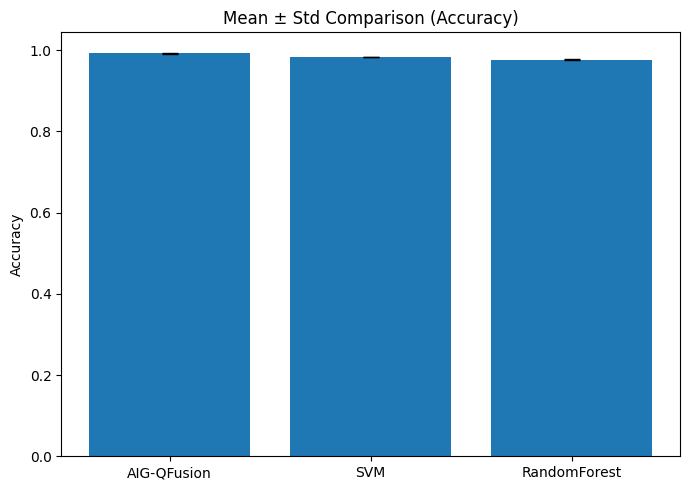

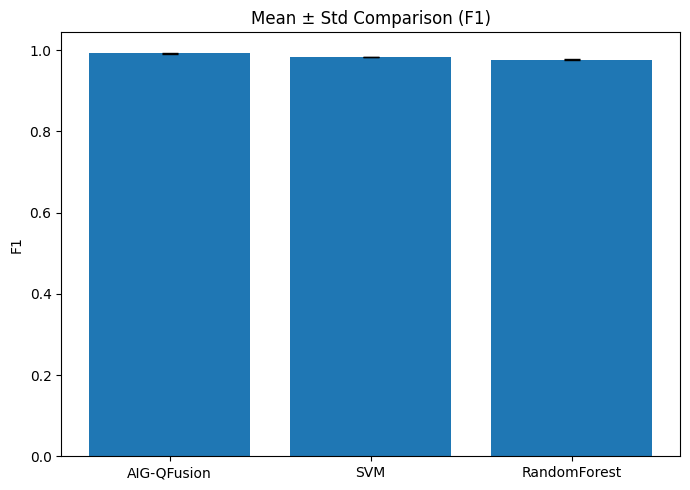

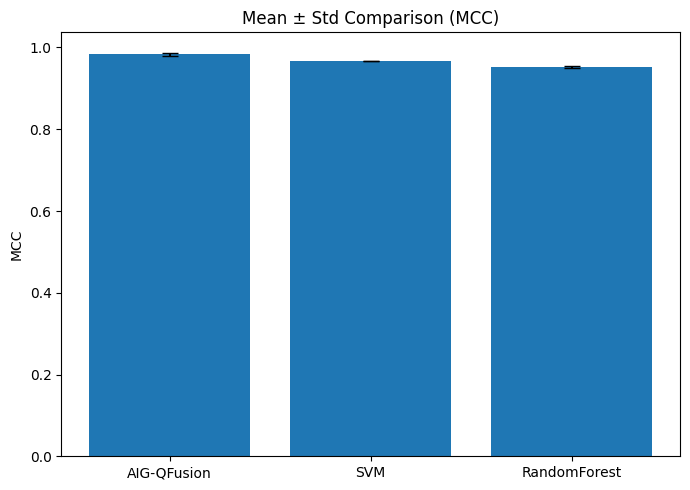

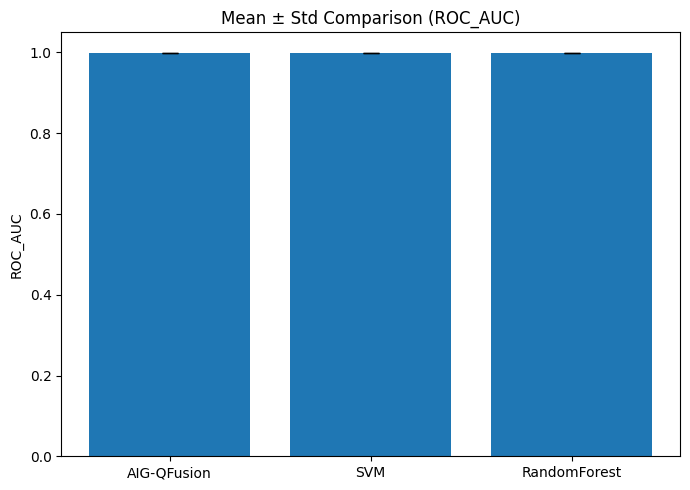

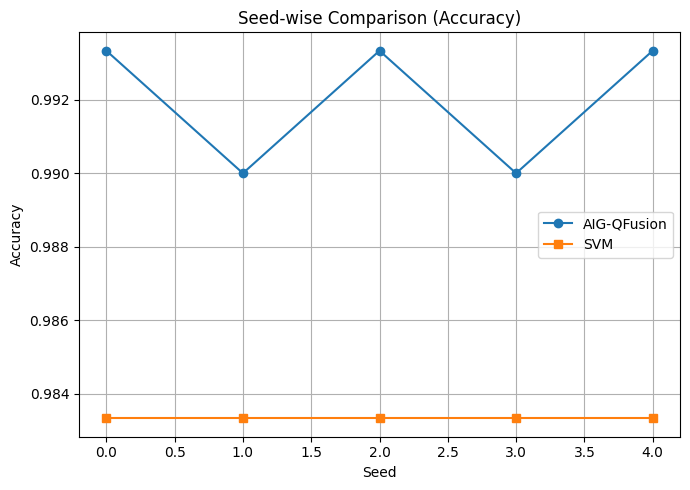

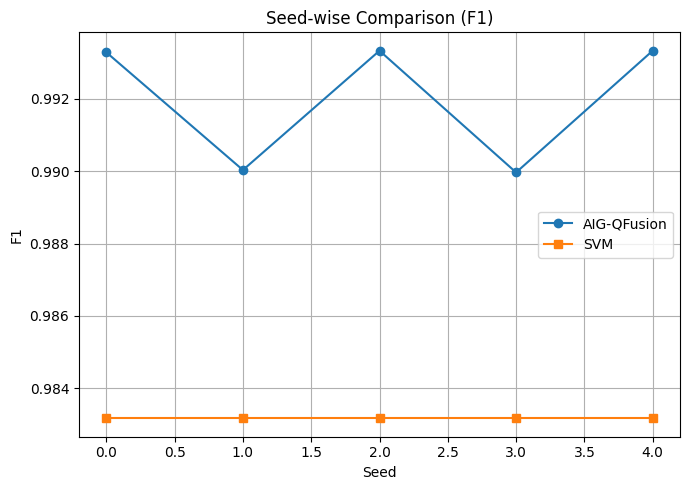

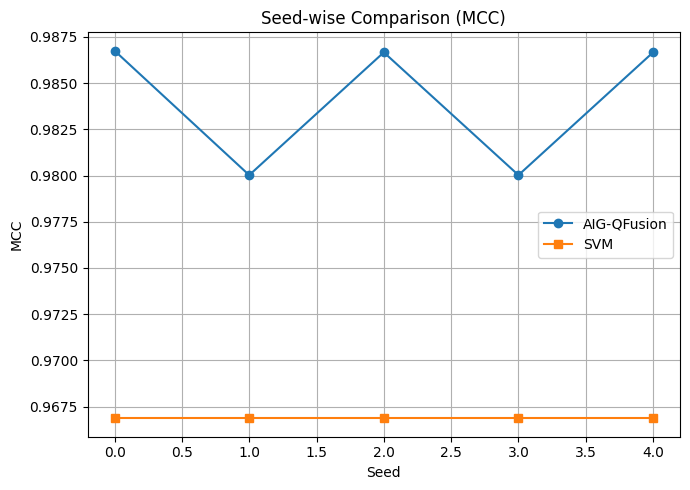

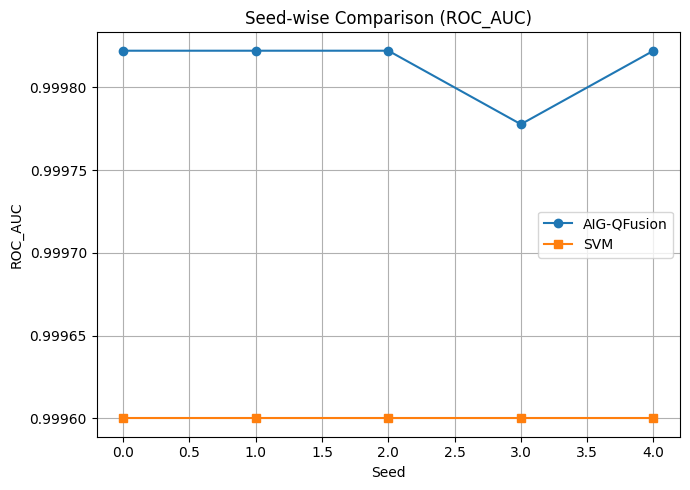

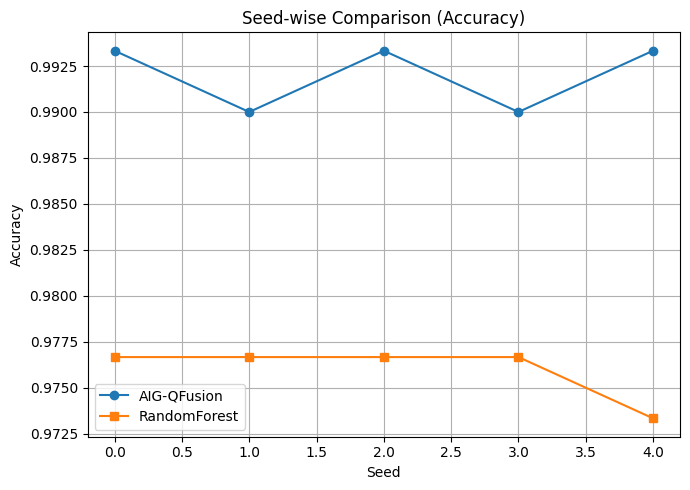

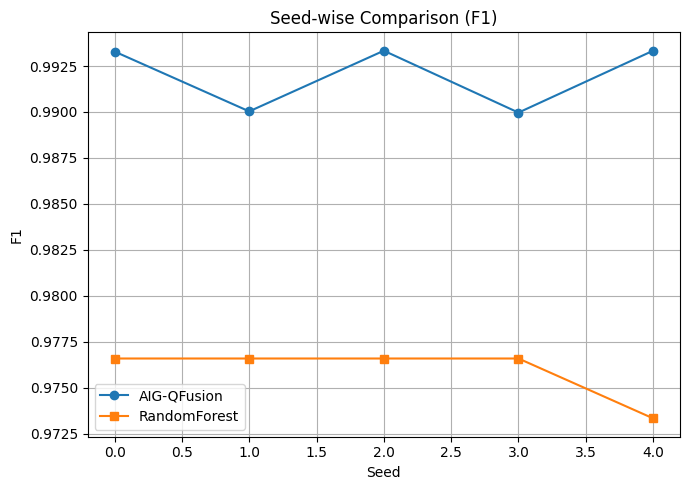

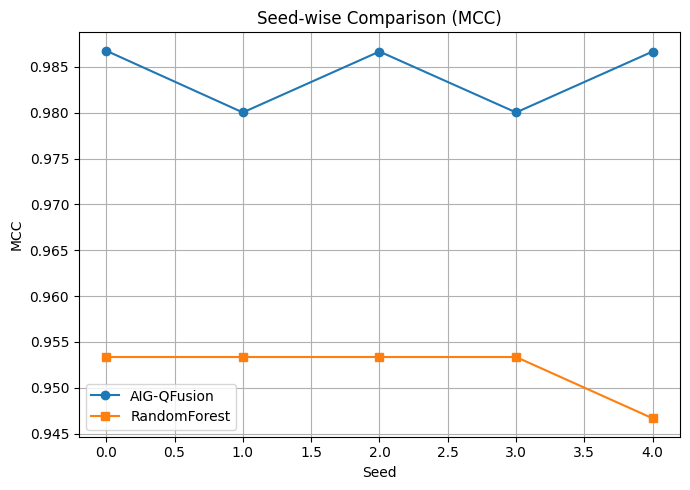

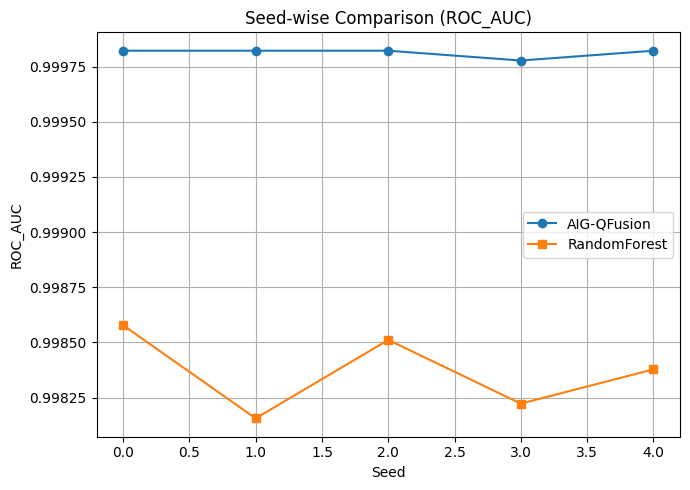

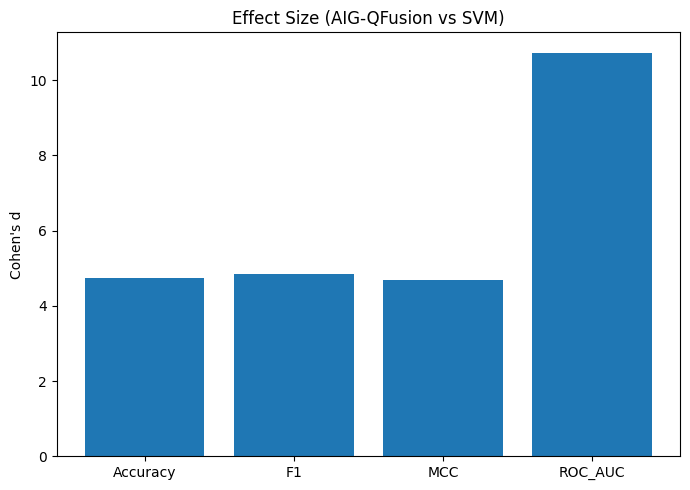

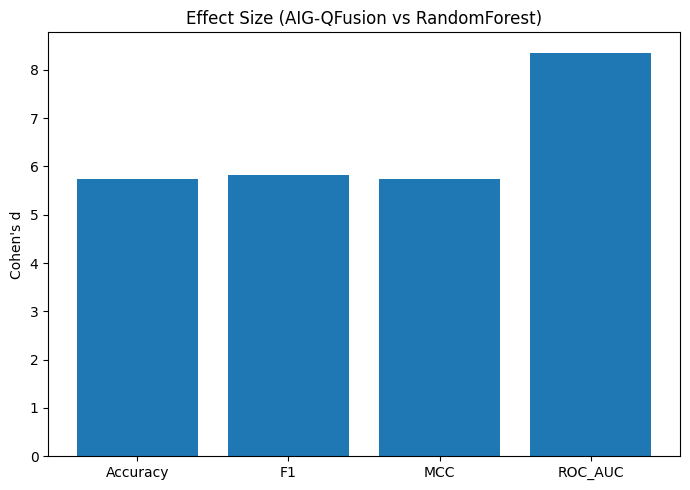


Graphs saved to:
 C:\Users\shanmugam\shan work 1\New folder\new try\output\graph_print_ready


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT FILES
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
BASELINE_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\graph_print_ready"
os.makedirs(OUT_DIR, exist_ok=True)

DATASET = "balanced"
PCA = 12

BASELINES = ["SVM", "RandomForest"]
METRICS = ["Accuracy","F1","MCC","ROC_AUC"]

# ============================================================
# LOAD DATA
# ============================================================
prop = pd.read_csv(PROPOSED_CSV)
base = pd.read_csv(BASELINE_CSV)

prop = prop[(prop["Dataset"]==DATASET) & (prop["PCA"]==PCA)]
base = base[(base["Dataset"]==DATASET) & (base["PCA"]==PCA)]

# ============================================================
# GRAPH 1 : MEAN ± STD BAR CHART
# ============================================================
for metric in METRICS:

    plt.figure(figsize=(7,5))

    labels = ["AIG-QFusion"] + BASELINES

    means=[]
    stds=[]

    means.append(prop[metric].mean())
    stds.append(prop[metric].std())

    for m in BASELINES:
        sub = base[base["Algorithm"]==m]
        means.append(sub[metric].mean())
        stds.append(sub[metric].std())

    x=np.arange(len(labels))

    plt.bar(x,means,yerr=stds,capsize=6)

    plt.xticks(x,labels)
    plt.ylabel(metric)
    plt.title(f"Mean ± Std Comparison ({metric})")
    plt.tight_layout()

    savepath=os.path.join(OUT_DIR,f"mean_std_{metric}.png")
    plt.savefig(savepath,dpi=600)  # high resolution for printing
    plt.show()


# ============================================================
# GRAPH 2 : SEED-WISE LINE PLOT
# ============================================================
for model in BASELINES:

    base_model=base[base["Algorithm"]==model].sort_values("Seed")

    merged=prop[["Seed"]+METRICS].merge(
        base_model[["Seed"]+METRICS],
        on="Seed",
        suffixes=("_prop","_base")
    )

    for metric in METRICS:

        plt.figure(figsize=(7,5))

        seeds=merged["Seed"]

        plt.plot(seeds,merged[f"{metric}_prop"],
                 marker="o",label="AIG-QFusion")

        plt.plot(seeds,merged[f"{metric}_base"],
                 marker="s",label=model)

        plt.xlabel("Seed")
        plt.ylabel(metric)
        plt.title(f"Seed-wise Comparison ({metric})")

        plt.legend()
        plt.grid(True)

        plt.tight_layout()

        savepath=os.path.join(OUT_DIR,f"seedwise_{metric}_{model}.png")
        plt.savefig(savepath,dpi=600)
        plt.show()


# ============================================================
# GRAPH 3 : EFFECT SIZE BAR PLOT
# (Using your computed Cohen's d values)
# ============================================================

effect_data={
"Metric":["Accuracy","F1","MCC","ROC_AUC"],
"SVM":[4.7469,4.8551,4.6957,10.7331],
"RandomForest":[5.7371,5.8198,5.7362,8.3567]
}

effect=pd.DataFrame(effect_data)

for model in ["SVM","RandomForest"]:

    plt.figure(figsize=(7,5))

    x=np.arange(len(effect["Metric"]))
    vals=effect[model]

    plt.bar(x,vals)

    plt.xticks(x,effect["Metric"])
    plt.ylabel("Cohen's d")

    plt.title(f"Effect Size (AIG-QFusion vs {model})")

    plt.tight_layout()

    savepath=os.path.join(OUT_DIR,f"effectsize_{model}.png")
    plt.savefig(savepath,dpi=600)
    plt.show()


print("\nGraphs saved to:\n",OUT_DIR)

# Over all comparison 

In [2]:
# ============================================================
# PAPER-STYLE STATISTICAL SUMMARY TABLE | PCA-12 ONLY
# Proposed vs Classical ML vs QML
#
# Output:
#   1) combined mean ± std table
#   2) highlighted Excel
#   3) styled HTML
# ============================================================

import os
import numpy as np
import pandas as pd

# ============================================================
# USER CONFIG
# ============================================================
PROPOSED_CSV = r"C:\Users\shanmugam\shan work 1\data\dataset_saved_500_300_pca4to12\AIGQFUSION_BALANCED_PCA4to12_outputs\raw_all_seeds_aigqfusion_balanced_pca4to12.csv"
CLASSICAL_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_ml_baselines_balanced_pca12.csv"
QML_CSV = r"C:\Users\shanmugam\shan work 1\New folder\new try\output\raw_all_seeds_qml_baselines_balanced_pca12_reduced50_20.csv"

OUT_DIR = r"C:\Users\shanmugam\shan work 1\New folder\new try\output"
os.makedirs(OUT_DIR, exist_ok=True)

PCA_K = 12
DATASET_NAME = "balanced"

# choose which models to include
CLASSICAL_MODELS = ["CatBoost", "DecisionTree", "GradientBoost", "KNN", "MLP", "RandomForest", "SVM", "XGBoost"]
QML_MODELS = ["QNN", "QSVM_Pauli", "QSVM_Z", "QSVM_ZZ", "VQC"]

# choose whether to include QML in same table
INCLUDE_QML = True

# ============================================================
# LOAD DATA
# ============================================================
prop_df = pd.read_csv(PROPOSED_CSV)
cls_df = pd.read_csv(CLASSICAL_CSV)
qml_df = pd.read_csv(QML_CSV)

# ============================================================
# FILTER PCA-12
# ============================================================
prop_df = prop_df[(prop_df["Dataset"] == DATASET_NAME) & (prop_df["PCA"] == PCA_K)].copy()
cls_df = cls_df[
    (cls_df["Dataset"] == DATASET_NAME) &
    (cls_df["PCA"] == PCA_K) &
    (cls_df["Algorithm"].isin(CLASSICAL_MODELS))
].copy()
qml_df = qml_df[
    (qml_df["Dataset"] == DATASET_NAME) &
    (qml_df["PCA"] == PCA_K) &
    (qml_df["Algorithm"].isin(QML_MODELS))
].copy()

# ============================================================
# COMMON METRIC COLUMNS
# ============================================================
metric_cols = [
    "Accuracy", "Precision", "Recall", "F1", "MCC",
    "ROC_AUC", "PR_AUC", "Brier", "ECE",
    "TrainTime_s", "TestTime_s", "TotalTime_s"
]

# ============================================================
# BUILD PROPOSED TABLE
# ============================================================
prop_mean = prop_df.groupby(["Dataset", "PCA"])[metric_cols].mean().reset_index()
prop_std  = prop_df.groupby(["Dataset", "PCA"])[metric_cols].std().reset_index()

prop_pm = prop_mean.copy()
for c in metric_cols:
    prop_pm[c] = prop_mean[c].map(lambda x: f"{x:.4f}") + " ± " + prop_std[c].map(lambda x: f"{x:.4f}")

prop_pm["Algorithm"] = "AIG-QFusion"

# reorder
prop_pm = prop_pm[["Dataset", "PCA", "Algorithm"] + metric_cols]

# ============================================================
# BUILD CLASSICAL TABLE
# ============================================================
cls_mean = cls_df.groupby(["Dataset", "PCA", "Algorithm"])[metric_cols].mean().reset_index()
cls_std  = cls_df.groupby(["Dataset", "PCA", "Algorithm"])[metric_cols].std().reset_index()

cls_pm = cls_mean.copy()
for c in metric_cols:
    cls_pm[c] = cls_mean[c].map(lambda x: f"{x:.4f}") + " ± " + cls_std[c].map(lambda x: f"{x:.4f}")

cls_pm = cls_pm[["Dataset", "PCA", "Algorithm"] + metric_cols]

# ============================================================
# BUILD QML TABLE
# ============================================================
qml_mean = qml_df.groupby(["Dataset", "PCA", "Algorithm"])[metric_cols].mean().reset_index()
qml_std  = qml_df.groupby(["Dataset", "PCA", "Algorithm"])[metric_cols].std().reset_index()

qml_pm = qml_mean.copy()
for c in metric_cols:
    qml_pm[c] = qml_mean[c].map(lambda x: f"{x:.4f}") + " ± " + qml_std[c].map(lambda x: f"{x:.4f}")

qml_pm = qml_pm[["Dataset", "PCA", "Algorithm"] + metric_cols]

# ============================================================
# COMBINE TABLES
# ============================================================
combined_pm = pd.concat(
    [prop_pm, cls_pm] + ([qml_pm] if INCLUDE_QML else []),
    axis=0,
    ignore_index=True
)

combined_mean = pd.concat(
    [prop_mean.assign(Algorithm="AIG-QFusion")[["Dataset", "PCA", "Algorithm"] + metric_cols],
     cls_mean[["Dataset", "PCA", "Algorithm"] + metric_cols]]
    + ([qml_mean[["Dataset", "PCA", "Algorithm"] + metric_cols]] if INCLUDE_QML else []),
    axis=0,
    ignore_index=True
)

# custom order
algo_order = ["AIG-QFusion"] + CLASSICAL_MODELS + (QML_MODELS if INCLUDE_QML else [])
combined_pm["Algorithm"] = pd.Categorical(combined_pm["Algorithm"], categories=algo_order, ordered=True)
combined_mean["Algorithm"] = pd.Categorical(combined_mean["Algorithm"], categories=algo_order, ordered=True)

combined_pm = combined_pm.sort_values(["PCA", "Algorithm"]).reset_index(drop=True)
combined_mean = combined_mean.sort_values(["PCA", "Algorithm"]).reset_index(drop=True)

# ============================================================
# HIGHLIGHT RULES
# ============================================================
higher_better = ["Accuracy", "Precision", "Recall", "F1", "MCC", "ROC_AUC", "PR_AUC"]
lower_better = ["Brier", "ECE", "TrainTime_s", "TestTime_s", "TotalTime_s"]

BEST_COLOR = "background-color: #d9ead3;"
BORDER = "1px solid black"

def highlight_best_cells(_):
    styles = pd.DataFrame("", index=combined_pm.index, columns=combined_pm.columns)

    for pca_val in combined_mean["PCA"].unique():
        mask = combined_mean["PCA"] == pca_val
        sub = combined_mean.loc[mask]

        for c in higher_better:
            best = sub[c].max()
            styles.loc[mask & np.isclose(combined_mean[c], best), c] = BEST_COLOR

        for c in lower_better:
            best = sub[c].min()
            styles.loc[mask & np.isclose(combined_mean[c], best), c] = BEST_COLOR

    return styles

# ============================================================
# STYLED TABLE
# ============================================================
sty = (
    combined_pm.style
    .apply(highlight_best_cells, axis=None)
    .set_properties(**{
        "text-align": "center",
        "vertical-align": "middle",
        "border": BORDER,
        "font-size": "11pt",
        "font-family": "Times New Roman"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("border", BORDER),
                ("width", "100%"),
            ]
        },
        {
            "selector": "th",
            "props": [
                ("border", BORDER),
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
                ("padding", "6px"),
                ("font-family", "Times New Roman"),
                ("font-size", "11pt")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", BORDER),
                ("text-align", "center"),
                ("vertical-align", "middle"),
                ("padding", "6px"),
                ("font-family", "Times New Roman"),
                ("font-size", "11pt")
            ]
        },
        {
            "selector": ".row_heading",
            "props": [
                ("border", BORDER),
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": ".blank",
            "props": [
                ("border", BORDER),
                ("background-color", "#f2f2f2")
            ]
        }
    ])
)

# ============================================================
# SAVE FILES
# ============================================================
csv_path = os.path.join(OUT_DIR, "combined_meanpmstd_pca12_allmodels.csv")
xlsx_path = os.path.join(OUT_DIR, "combined_highlighted_meanpmstd_pca12_allmodels.xlsx")
html_path = os.path.join(OUT_DIR, "combined_highlighted_meanpmstd_pca12_allmodels.html")

combined_pm.to_csv(csv_path, index=False)

try:
    sty.to_excel(xlsx_path, engine="openpyxl", index=True)
    print("Highlighted Excel saved:", xlsx_path)
except Exception as e:
    print("Excel export skipped:", e)

try:
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(sty.to_html())
    print("Styled HTML saved:", html_path)
except Exception as e:
    print("HTML export skipped:", e)

print("\n=== COMBINED MEAN ± STD TABLE | PCA-12 ===\n")
try:
    from IPython.display import display
    display(sty)
except Exception:
    print(combined_pm.to_string(index=False))

print("\nSaved files:")
print(csv_path)
print(xlsx_path)
print(html_path)
print("\nDone.")

Highlighted Excel saved: C:\Users\shanmugam\shan work 1\New folder\new try\output\combined_highlighted_meanpmstd_pca12_allmodels.xlsx
Styled HTML saved: C:\Users\shanmugam\shan work 1\New folder\new try\output\combined_highlighted_meanpmstd_pca12_allmodels.html

=== COMBINED MEAN ± STD TABLE | PCA-12 ===



,Dataset,PCA,Algorithm,Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,Brier,ECE,TrainTime_s,TestTime_s,TotalTime_s
0,balanced,12,AIG-QFusion,0.9920 ± 0.0018,0.9933 ± 0.0047,0.9907 ± 0.0037,0.9920 ± 0.0018,0.9840 ± 0.0037,0.9998 ± 0.0000,0.9998 ± 0.0000,0.0076 ± 0.0004,0.5031 ± 0.0026,52.7203 ± 7.1165,0.0151 ± 0.0022,52.7354 ± 7.1155
1,balanced,12,CatBoost,0.9720 ± 0.0038,0.9720 ± 0.0055,0.9720 ± 0.0030,0.9720 ± 0.0038,0.9440 ± 0.0076,0.9982 ± 0.0002,0.9982 ± 0.0002,0.0177 ± 0.0010,0.4852 ± 0.0042,0.6335 ± 0.0759,0.0014 ± 0.0008,0.6349 ± 0.0767
2,balanced,12,DecisionTree,0.9367 ± 0.0113,0.9556 ± 0.0122,0.9160 ± 0.0203,0.9353 ± 0.0119,0.8743 ± 0.0224,0.9367 ± 0.0113,0.9173 ± 0.0141,0.0633 ± 0.0113,0.5000 ± 0.0000,0.0044 ± 0.0009,0.0002 ± 0.0004,0.0046 ± 0.0009
3,balanced,12,GradientBoost,0.9653 ± 0.0018,0.9666 ± 0.0001,0.9640 ± 0.0037,0.9653 ± 0.0019,0.9307 ± 0.0036,0.9960 ± 0.0001,0.9962 ± 0.0001,0.0254 ± 0.0001,0.4786 ± 0.0012,0.3260 ± 0.0066,0.0019 ± 0.0025,0.3279 ± 0.0078
4,balanced,12,KNN,0.9600 ± 0.0000,0.9423 ± 0.0000,0.9800 ± 0.0000,0.9608 ± 0.0000,0.9207 ± 0.0000,0.9924 ± 0.0000,0.9886 ± 0.0000,0.0294 ± 0.0000,0.4608 ± 0.0000,0.0025 ± 0.0010,0.0032 ± 0.0004,0.0057 ± 0.0015
5,balanced,12,MLP,0.9560 ± 0.0229,0.9809 ± 0.0200,0.9307 ± 0.0480,0.9544 ± 0.0252,0.9143 ± 0.0426,0.9932 ± 0.0061,0.9941 ± 0.0050,0.1011 ± 0.0406,0.4769 ± 0.0187,0.0421 ± 0.0040,0.0011 ± 0.0001,0.0431 ± 0.0040
6,balanced,12,RandomForest,0.9760 ± 0.0015,0.9786 ± 0.0029,0.9733 ± 0.0000,0.9759 ± 0.0015,0.9520 ± 0.0030,0.9984 ± 0.0002,0.9984 ± 0.0002,0.0243 ± 0.0006,0.4796 ± 0.0020,0.3956 ± 0.0035,0.0694 ± 0.0008,0.4650 ± 0.0043
7,balanced,12,SVM,0.9833 ± 0.0000,0.9932 ± 0.0000,0.9733 ± 0.0000,0.9832 ± 0.0000,0.9669 ± 0.0000,0.9996 ± 0.0000,0.9996 ± 0.0000,0.0100 ± 0.0002,0.4989 ± 0.0011,0.0151 ± 0.0010,0.0025 ± 0.0005,0.0176 ± 0.0007
8,balanced,12,XGBoost,0.9713 ± 0.0038,0.9732 ± 0.0002,0.9693 ± 0.0076,0.9713 ± 0.0039,0.9427 ± 0.0076,0.9977 ± 0.0001,0.9978 ± 0.0000,0.0178 ± 0.0006,0.4902 ± 0.0039,0.0746 ± 0.0105,0.0020 ± 0.0007,0.0766 ± 0.0110
9,balanced,12,QNN,0.4800 ± 0.1304,0.4878 ± 0.1068,0.6600 ± 0.1517,0.5583 ± 0.1142,-0.0424 ± 0.2707,0.4800 ± 0.1304,0.5013 ± 0.0642,0.3126 ± 0.0603,0.2311 ± 0.0000,121.5763 ± 0.7251,0.6075 ± 0.0238,122.1838 ± 0.7261



Saved files:
C:\Users\shanmugam\shan work 1\New folder\new try\output\combined_meanpmstd_pca12_allmodels.csv
C:\Users\shanmugam\shan work 1\New folder\new try\output\combined_highlighted_meanpmstd_pca12_allmodels.xlsx
C:\Users\shanmugam\shan work 1\New folder\new try\output\combined_highlighted_meanpmstd_pca12_allmodels.html

Done.
